customer-sentiment-analysis

In [2]:
!pip install tensorflow
!pip install wordcloud

In [323]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import re

#Task 2 libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import unicodedata
import nltk
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
tf.__version__


'2.21.0'

In [5]:
tf.random.set_seed(1)


This dataset was created for the Paper 'From Group to Individual Labels using Deep Features', Kotzias et. al,. KDD 2015
Please cite the paper if you want to use it :)

It contains sentences labelled with positive or negative sentiment, extracted from reviews of products, movies, and restaurants

=======
Format:
=======
sentence \t score \n


=======
Details:
=======
Score is either 1 (for positive) or 0 (for negative)	
The sentences come from three different websites/fields:

imdb.com
amazon.com
yelp.com

For each website, there exist 500 positive and 500 negative sentences. Those were selected randomly for larger datasets of reviews. 
We attempted to select sentences that have a clearly positive or negative connotaton, the goal was for no neutral sentences to be selected.



For the full datasets look:

imdb: Maas et. al., 2011 'Learning word vectors for sentiment analysis'
amazon: McAuley et. al., 2013 'Hidden factors and hidden topics: Understanding rating dimensions with review text'
yelp: Yelp dataset challenge http://www.yelp.com/dataset_challenge


In [7]:
#Import data
#make sure to remove quotes, get rid of punctuation etc
#it's delimited by tab so change argument to acknowledge it

imdb_df = pd.read_csv("imdb_labelled.txt", delimiter="\t", header=None
)

amazon_df = pd.read_csv( "amazon_cells_labelled.txt", delimiter="\t", header=None
)

yelp_df = pd.read_csv( "yelp_labelled.txt", delimiter="\t", header=None
)

In [8]:
print(imdb_df)



                                                     0  1
0    A very, very, very slow-moving, aimless movie ...  0
1    Not sure who was more lost - the flat characte...  0
2    Attempting artiness with black & white and cle...  0
3         Very little music or anything to speak of.    0
4    The best scene in the movie was when Gerardo i...  1
..                                                 ... ..
743  I just got bored watching Jessice Lange take h...  0
744  Unfortunately, any virtue in this film's produ...  0
745                   In a word, it is embarrassing.    0
746                               Exceptionally bad!    0
747  All in all its an insult to one's intelligence...  0

[748 rows x 2 columns]


In [9]:
print(imdb_df.count())

print(amazon_df.count())

print(yelp_df.count())

0    748
1    748
dtype: int64
0    1000
1    1000
dtype: int64
0    1000
1    1000
dtype: int64


In [10]:
print(imdb_df.head(50))

                                                    0  1
0   A very, very, very slow-moving, aimless movie ...  0
1   Not sure who was more lost - the flat characte...  0
2   Attempting artiness with black & white and cle...  0
3        Very little music or anything to speak of.    0
4   The best scene in the movie was when Gerardo i...  1
5   The rest of the movie lacks art, charm, meanin...  0
6                                 Wasted two hours.    0
7   Saw the movie today and thought it was a good ...  1
8                                A bit predictable.    0
9   Loved the casting of Jimmy Buffet as the scien...  1
10               And those baby owls were adorable.    1
11  The movie showed a lot of Florida at it's best...  1
12  The Songs Were The Best And The Muppets Were S...  1
13                                  It Was So Cool.    1
14  This is a very "right on case" movie that deli...  1
15  It had some average acting from the main perso...  0
16  This review is long overdue

IMDB is missing over 200 rows
Each website should have 1000 rows, 500 positive and 500 negative

Checking IMDB txt file I see that some of the data starts with semi colon and parenthesis, this breaks the data and it doesn't register.
Some of them are quotes and long which breaks the lines
Reimport



In [12]:

imdb_df = pd.read_csv("imdb_labelled.txt", quoting=csv.QUOTE_NONE, delimiter='\t', header=None)
amazon_df = pd.read_csv("amazon_cells_labelled.txt", quoting=csv.QUOTE_NONE, delimiter='\t', header=None)
yelp_df = pd.read_csv("yelp_labelled.txt", quoting=csv.QUOTE_NONE, delimiter='\t', header=None)



In [13]:
print(imdb_df.head())

                                                   0  1
0  A very, very, very slow-moving, aimless movie ...  0
1  Not sure who was more lost - the flat characte...  0
2  Attempting artiness with black & white and cle...  0
3       Very little music or anything to speak of.    0
4  The best scene in the movie was when Gerardo i...  1


In [14]:
print(imdb_df.count())
print(amazon_df.count())
print(yelp_df.count())

0    1000
1    1000
dtype: int64
0    1000
1    1000
dtype: int64
0    1000
1    1000
dtype: int64


All rows are available, resolved


In [16]:
#Rename the columns to match column content


imdb_df.columns = ["review", "sentiment"]
amazon_df.columns = ["review", "sentiment"]
yelp_df.columns = ["review", "sentiment"]

In [17]:
print(imdb_df.head(5))
print(amazon_df.head(5))
print(yelp_df.head(5))

                                              review  sentiment
0  A very, very, very slow-moving, aimless movie ...          0
1  Not sure who was more lost - the flat characte...          0
2  Attempting artiness with black & white and cle...          0
3       Very little music or anything to speak of.            0
4  The best scene in the movie was when Gerardo i...          1
                                              review  sentiment
0  So there is no way for me to plug it in here i...          0
1                        Good case, Excellent value.          1
2                             Great for the jawbone.          1
3  Tied to charger for conversations lasting more...          0
4                                  The mic is great.          1
                                              review  sentiment
0                           Wow... Loved this place.          1
1                                 Crust is not good.          0
2          Not tasty and the texture was

In [18]:
#Concat the dataset together

df = pd.concat([imdb_df, amazon_df, yelp_df])
df.reset_index(inplace=True)

In [19]:
print(df.count())

index        3000
review       3000
sentiment    3000
dtype: int64


In [20]:
print(df.shape)

(3000, 3)


In [21]:
print(df.head())

   index                                             review  sentiment
0      0  A very, very, very slow-moving, aimless movie ...          0
1      1  Not sure who was more lost - the flat characte...          0
2      2  Attempting artiness with black & white and cle...          0
3      3       Very little music or anything to speak of.            0
4      4  The best scene in the movie was when Gerardo i...          1


In [22]:
df.describe()

,index,sentiment
count,3000.000000,3000.000000
mean,499.500000,0.500000
std,288.723115,0.500083
min,0.000000,0.000000
25%,249.750000,0.000000
50%,499.500000,0.500000
75%,749.250000,1.000000
max,999.000000,1.000000


In [23]:
print(df.sentiment.unique())

[0 1]


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   index      3000 non-null   int64
 1   review     3000 non-null   str  
 2   sentiment  3000 non-null   int64
dtypes: int64(2), str(1)
memory usage: 261.7 KB


In [25]:
df.isnull().sum()

index        0
review       0
sentiment    0
dtype: int64

No missing values detected


In [27]:
df.duplicated().sum()

0

No duplicates detected


Okay so there confirmed only positive and negative sentiments
It will be a binary classification problem


In [30]:
df.sample(20)

,index,review,sentiment
184,184,Not a pleasant voyage of self-discovery.,0
1956,956,Just reading on the specs alone makes you say ...,1
221,221,There are the usual Hitchcock logic flaws.,0
1144,144,The phone takes FOREVER to charge like 2 to 5 ...,0
2543,543,I won't try going back there even if it's empty.,0
154,154,"Again, no plot at all.",0
323,323,"The ending is so, SO perfect... you'll shed a ...",1
1614,614,the worst phone from samsung...crap..... this ...,0
1242,242,Worst Customer Service Ever.,0
1943,943,I'm returning them.,0


In [31]:
df['sentiment'].value_counts()

sentiment
0    1500
1    1500
Name: count, dtype: int64

<Axes: xlabel='sentiment', ylabel='count'>

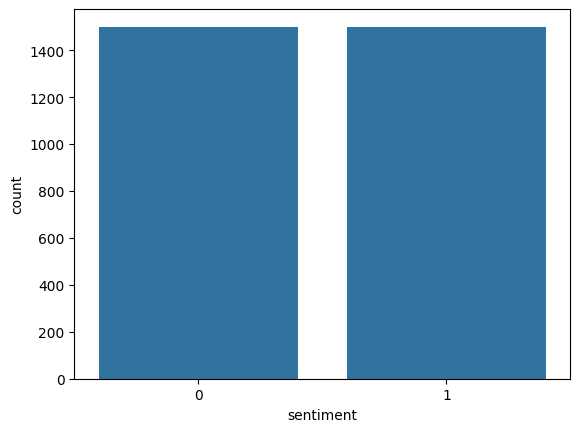

In [32]:
sns.countplot(data = df, x = 'sentiment')

Counts of sentiment is adequate. Each website should have 500 positive and 500 negative
0 for negative sentiment
1 for positive sentiment


Data is not so skewed, so the model will be fairly decent as it won't be biased towards negative or positive


In [35]:
#download the stop words

nltk.download('stopwords')

#print stop words

stop_words = (nltk.corpus.stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
#Download the lemmatizer from nltk
#Lemmatizer is to reduce the word to its base form, requirement of Dr. Sewell and Dr. Aly
nltk.download("wordnet")
nltk.download("omw-1.4")



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nam\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [37]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [38]:
# Dataset summary before creating total_words and total_chars and cleaning data

print("Number of Reviews:", len(df))

print("Positive Reviews:", (df["sentiment"] == 1).sum())
print("Negative Reviews:", (df["sentiment"] == 0).sum())

raw_words = df["review"].apply(lambda x: len(str(x).split())).sum()
print("Total Words:", raw_words)

raw_chars = df["review"].apply(lambda x: len(str(x))).sum()
print("Total Characters:", raw_chars)

raw_vocab = len(set(" ".join(df["review"].astype(str)).split()))
print("Vocabulary Size:", raw_vocab)


Number of Reviews: 3000
Positive Reviews: 1500
Negative Reviews: 1500
Total Words: 35495
Total Characters: 195814
Vocabulary Size: 8015


We will need this summary to answer questions with a before and after


In [40]:
# Find rows containing unusual characters

#Using contains with ^ to ask for NOT IN, \x00-\x7f (ASCII characters which is the letters, 0-9 and standard punctuation (Which will be cleared out in future cells)

unicode_rows = df[df["review"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)]

print("Rows containing unusual characters:", len(unicode_rows))

unicode_rows.head()

Rows containing unusual characters: 17


,index,review,sentiment
18,18,It's practically perfect in all of them  a tr...,1
80,80,I'm glad this pretentious piece of s*** didn't...,0
178,178,The script is was there a script?,0
182,182,I'll even say it again  this is torture.,0
424,424,This show is made for Americans - it is too st...,0


In [41]:
#Checking to see if it has letters with accent marks 

df[df["review"].str.contains("é", na=False)]

,index,review,sentiment
80,80,I'm glad this pretentious piece of s*** didn't...,0
424,424,This show is made for Americans - it is too st...,0
469,469,A cheap and cheerless heist movie with poor ch...,0
767,767,I am so tired of clichés that is just lazy wri...,0
2150,150,My fiancé and I came in the middle of the day ...,1
2598,598,I really enjoyed Crema Café before they expand...,1
2915,915,The only thing I wasn't too crazy about was th...,0


Okay so the code does have non "standard letters". this will need to be changed from é to e 

In [43]:
#Swap unicode, basically change the accented letters to non-accented


replacement_dict = {
    "é": "e",
    "è": "e",
    "ê": "e",
    "ë": "e",
    "á": "a",
    "à": "a",
    "â": "a",
    "ä": "a",
    "í": "i",
    "ì": "i",
    "î": "i",
    "ï": "i",
    "ó": "o",
    "ò": "o",
    "ô": "o",
    "ö": "o",
    "ú": "u",
    "ù": "u",
    "û": "u",
    "ü": "u",
    "ç": "c",
    "ñ": "n",
    "å": "a"
}

for old, new in replacement_dict.items():
    df["review"] = df["review"].str.replace(old, new, regex=False)

In [44]:
print(df.loc[424])

index                                                      424
review       This show is made for Americans - it is too st...
sentiment                                                    0
Name: 424, dtype: object


In [45]:
accented_chars = set()

for text in df["review"]:
    for char in text:
        if ord(char) > 127:
            accented_chars.add(char)


print(sorted(accented_chars))

#Okay this will be addressed in future cells with regex


['\x85', '\x96', '\x97']


In [46]:
#Prepare the dataset
#Convert all to lower string
#Replace punctuations with space using regrex

df["review"] = df["review"].str.lower()



In [47]:
#Keep only non stop words

df["review"] = df["review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [48]:
#Brackets = match one character from this group
# ^ = NOT
#\w = word characters
#\s white space 
#basically means match any character that is not a word character or whitespace

df["review"] = df["review"].str.replace(
    r"[^\w\s]",
    " ",
    regex=True
)

In [49]:

print(df.sample(20))

      index                                             review  sentiment
2370    370              left stomach ache felt sick rest day           0
2107    107                  ambience wonderful music playing           1
2904    904                                  my order correct           0
867     867                                       great movie           1
864     864  scripting subtle comedy unmatched movie recent...          1
2506    506                            overall impressed noca           0
2209    209  sides delish   mixed mushrooms  yukon gold pur...          1
263     263  conceptually  show offers little bit everythin...          1
2971    971                              ambiance much better           0
854     854  trouble is  writing directing make impossible ...          0
1473    473                          great software motorolas           1
1247    247                  nice headphones price work great           1
1518    518                           

In [50]:
#Remove index column, as there are two index columns

df = df.drop(columns = ['index'])

In [51]:

print(df.sample(20))

                                                 review  sentiment
772   learn lot real inside emotions people movie  l...          1
1720  good value  works fine   power via usb  car  w...          1
2174  everything menu terrific also thrilled made am...          1
163                think ever gone movie disliked much           0
51    addition one lovely songs ever written  french...          1
1754  camera phone may used dustpan indoors    rathe...          0
2690                                absolutely amazing           1
101   frankly  cotton club unfaithful  kind embarras...          0
864   scripting subtle comedy unmatched movie recent...          1
2824                                     awful service           0
1491  super charged use small hybrid palmtop camera ...          1
929   movie completely perfect  titta di girolamo  s...          1
359    things four kids get absolutely hilarious watch           1
2506                            overall impressed noca        

In [52]:
#Strip the white spaces at the beginning and end of sentences just in case

df["review"] = df["review"].str.strip()

In [53]:
print(df.sample(10))

                                                 review  sentiment
367      new characters memorable  found forgetting who          0
1866  choice headset years great sound  good volume ...          1
2755               side town  definitely spot hit again          1
2682                       dessert  panna cotta amazing          1
2293  live neighborhood disappointed back here  conv...          0
1729               receiving using product 2 days broke          0
421   movie excellent angel beautiful scamp adorable...          1
552                               bad   well   it s bad          0
342                  educational children 1 8 years old          1
2410                            know kind best iced tea          1


In [54]:
#Check that line

print(df.iloc[2326,])

review       disappointed
sentiment               1
Name: 2326, dtype: object


In [55]:
#Make sure there are no empty reviews
print((df["review"] == "").sum())

0


In [56]:
print(df.head())

                                              review  sentiment
0  very  very  slow moving  aimless movie distres...          0
1  sure lost   flat characters audience  nearly h...          0
2  attempting artiness black   white clever camer...          0
3                     little music anything speak of          0
4  best scene movie gerardo trying find song keep...          1


In [57]:
print(type(df["review"].iloc[0]))

<class 'str'>


In [58]:
print(df.duplicated().sum())

61


In [59]:
#check what rows are duplicated

duplicates = df[df.duplicated()]

print(duplicates.head(20))

                             review  sentiment
235                        horrible          0
257                           funny          1
363   definitely worth checking out          1
418                       movie bad          0
585                     recommended          0
615                           funny          1
766                          boring          0
788                           10 10          1
801                     avoid costs          0
837                      waste time          0
867                     great movie          1
886                     avoid costs          0
1143                   disappointed          0
1146                     waste time          0
1262                    works great          1
1285                    great phone          1
1290                    great phone          1
1300                   sending back          0
1337                  disappointing          0
1366                    waste money          0


In [60]:
#Removing duplicates
print(df.shape)

df = df.drop_duplicates()

print(df.shape)

print(df.duplicated().sum())

(3000, 2)
(2939, 2)
0


<Axes: xlabel='sentiment', ylabel='count'>

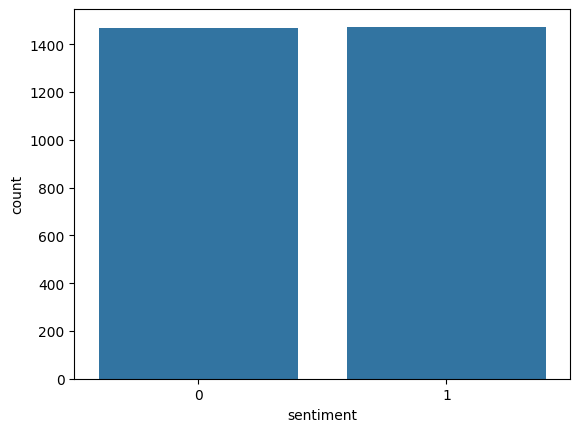

In [61]:
sns.countplot(data = df, x = 'sentiment')

In [62]:

print(df['sentiment'].value_counts())

sentiment
1    1473
0    1466
Name: count, dtype: int64


In [63]:
#Check for empty reviews

print((df["review"] == "").sum())

0


In [64]:
print(df.sample(20))

                                                 review  sentiment
567   cg opening sequence space looked like could cr...          0
2226                               unbelievable bargain          1
1473                           great software motorolas          1
627                  saw film christmas  great film was          1
989   anyway  plot flowed smoothly male bonding scen...          1
1815    checked everywhere feature really disappointing          0
166   bad film  bad writing  good actors    an ugly ...          0
2259                                 tough short flavor          0
1849                          bought two neither charge          0
1030     simple little phone use  breakage unacceptible          0
739                                    earth irons film          0
1765  addition feels  amp  looks phone lightweight c...          0
303    think one people found another one roth s pearls          1
2473                                    waste time here       

In [65]:
#Check for Unusual characters
#Basically match any character not is not ASCII
#Since accented letters are already swap for their ASCII base. This should clean it off emojis, chinese characters, pound symbols

df[df["review"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)]

,review,sentiment


In [66]:
#Check for html tags

html_rows = df[df["review"].str.contains(r"<.*?>", regex=True, na=False)]

print(len(html_rows))

0


In [67]:
#check for site links 

url_rows = df[df["review"].str.contains( r"http|www\.", regex=True, na=False )]

print(len(url_rows))

0


In [68]:
#Check for emojis

emoji_rows = df[df["review"].str.contains( r"[^\x00-\x7F]", regex=True, na=False )]

print(len(emoji_rows))

0


In [69]:
#Check for numbers

number_rows = df[df["review"].str.contains( r"\d", regex=True, na=False )]

print(len(number_rows))

233


In [70]:
#Check what contains numbers

print(number_rows["review"].head(20))

40     idea lame   take minor character mediocre pg 1...
53     negative  insipid enough cause regret another ...
61                              give one resounding 9 10
74                        say worth 2 hours time  though
81                            first movie given 10 years
86                                               gave 10
125                                                10 10
137    imdb ratings go low 1 awful  time get negative...
149    possible way movie could redeemed would mst3k ...
164    good thing tickets cost five dollars would mad...
228                   first watched movie  80s  loved it
291                                         rating  1 10
301                                  10 10 movie trilogy
305    story told eloquently francis ford coppola 25 ...
308    translating movies living first movie 5 year w...
330    hockey scenes terrible  defensemen playing lik...
342                   educational children 1 8 years old
353           would give televi

In [71]:
print(df.head())

                                              review  sentiment
0  very  very  slow moving  aimless movie distres...          0
1  sure lost   flat characters audience  nearly h...          0
2  attempting artiness black   white clever camer...          0
3                     little music anything speak of          0
4  best scene movie gerardo trying find song keep...          1


In [72]:
print(df.loc[0, "review"])

very  very  slow moving  aimless movie distressed  drifting young man


In [73]:
print(imdb_df.shape)
print(amazon_df.shape)
print(yelp_df.shape)

(1000, 2)
(1000, 2)
(1000, 2)


In [74]:
#There are some double spaces. replace spaces that are double and more with a single space

df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)

In [75]:
#Restrip because replacing could leave edge cases
df["review"] = df["review"].str.strip()

In [76]:
print(df.loc[0, "review"])

very very slow moving aimless movie distressed drifting young man


In [77]:
#Check for @
at_rows = df[df["review"].str.contains("@", na=False)]
print(len(at_rows))

0


In [78]:
#Check for new lines

df["review"].str.contains("\n", regex=False).sum()

0

In [79]:
#Are negative sentiments longer than positive sentiments?
#Count the number of letters for eachs string, then use mean/median to see if positive sentiments are longer/shorter

df["total_words"] = df["review"].apply(lambda x: len(x.split()))

# Count characters (including spaces)
df["total_chars"] = df["review"].apply(len)

df.groupby("sentiment")[["total_words", "total_chars"]].describe()

total_words                                                \
                count      mean       std  min  25%  50%  75%   max   
sentiment                                                             
0              1466.0  6.396999  4.113820  1.0  3.0  5.0  8.0  32.0   
1              1473.0  6.646300  4.670292  1.0  3.0  5.0  9.0  46.0   

          total_chars                                                       
                count       mean        std  min   25%   50%    75%    max  
sentiment                                                                   
0              1466.0  40.985675  27.362972  2.0  21.0  35.0  54.75  219.0  
1              1473.0  43.367957  32.376968  4.0  21.0  35.0  57.00  357.0

The averages are mostly identical, this mean that the model won't have a strong bias towards either side as more data to feed = more bias

Knowing the Max words will be useful for maxlength and padding


In [81]:
df["total_words"].describe()

count    2939.000000
mean        6.521946
std         4.402539
min         1.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        46.000000
Name: total_words, dtype: float64

In [82]:
#Checking to see special characters are removed

accented_chars = set()

for text in df["review"]:
    for char in text:
        if ord(char) > 127:
            accented_chars.add(char)

print(sorted(accented_chars))

#They are removed


[]



Though the dataset isn't exactly 1500 positive and 1500 negative because of duplicate reviews
But it's a very small difference that shouldn't influence bias


In [84]:
print(df.loc[300])

review         recommend everyone loves film movies anything ...
sentiment                                                      1
total_words                                                    9
total_chars                                                   56
Name: 300, dtype: object


In [85]:
print(df.loc[31])

review         waste money game
sentiment                     1
total_words                   3
total_chars                  16
Name: 31, dtype: object


In [86]:

print(df.sample(20))

                                                 review  sentiment  \
430   hate writing bad reviews films especially real...          0   
1781  bought hoping could make bluetooth headset fit...          0   
1636                                           fabulous          1   
1555                                        aggravating          0   
113                    sometimes embarrassing look away          0   
115         scenes oh so mature neighbour girl misplace          0   
1780                                sorry made purchase          0   
2271                            cant go wrong food here          1   
1620  steer clear product go genuine palm replacemen...          0   
238                                         poor actors          0   
1648         placed treo case snug lot extra room sides          0   
2156  different cut piece day still wonderful tender...          1   
2251            nothing privileged working eating there          0   
2749  wonderful lil 

In [87]:
#Remove all digits
#Normalize all white space

#\d is all digits,  + means more than one
df["review"] = df["review"].str.replace(r"\d+", "", regex=True)

#\s is white space, tabs, etc
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)
df["review"] = df["review"].str.strip()

In [88]:
print(df.sample(20))

                                                 review  sentiment  \
2470                                        good though          1   
892   one boring horror movies s mainly starts slow ...          0   
357   know exactly movie latched endearing movie bec...          1   
2824                                      awful service          0   
1219                             still infatuated phone          1   
2438                                wow spicy delicious          1   
429                      oh yeah storyline pathetic too          0   
100                                  think disappointed          1   
2110           real sushi lovers let s honest yama good          0   
1956                  reading specs alone makes say wow          1   
324                     thrilled seeing movie like this          1   
2286                  things went wrong burned saganaki          0   
1419                    plastic breaks really easy clip          0   
987   movie well bal

I noticed standalone 's'
from words like joey's 
they will be removed


In [90]:
#Checking how many stand alone 's' there is

df["review"].str.contains(r"\bs\b", regex=True, na=False).sum()

print(df[df["review"].str.contains(r"\bs\b", regex=True, na=False)].head(20))

                                                review  sentiment  \
48    whatever cost much translate quality that s sure          0   
59     sam shepard s portrayal gung ho marine sobering          1   
77   want movie that s gross gives chills great choice          1   
80   glad pretentious piece s planned dodge stratus...          0   
98   ursula burton s portrayal nun touching funny t...          1   
168  still like movie empowerment women there s eno...          1   
186                     premise sound stupid that s is          0   
211  owns film spacek owned coal miner s daughter q...          1   
228                     first watched movie s loved it          1   
240  check director s filmography site see film chance          0   
274  black water thriller manages completely transc...          1   
275  performances real gripping crocdodile extremel...          1   
282                      here s movie really pi ed off          0   
303   think one people found anoth

In [91]:
#Removing standalone 's'

#   \b means boundary, so two of them sandwhiching the s ensures that it deletes only 's' that has a space preceding and after
df["review"] = df["review"].str.replace(r"\bs\b", "", regex=True)

# Clean up extra space 
#stripping space from beginning and end

df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)
df["review"] = df["review"].str.strip()

In [92]:
#double checking for standalone s

df["review"].str.contains(r"\bs\b", regex=True, na=False).sum()

print(df[df["review"].str.contains(r"\bs\b", regex=True, na=False)].head(20))


Empty DataFrame
Columns: [review, sentiment, total_words, total_chars]
Index: []


In [93]:
print(df.sample(100))

                                                 review  sentiment  \
2003  stopped late may bank holiday rick steve recom...          1   
1104  received supposedly new motorola apparently ma...          0   
1307  many people complained found headset microphon...          0   
1287                                         piece junk          0   
2238      rolled eyes may stayed sure go back try again          0   
...                                                 ...        ...   
1336                         obviously problem adhesive          0   
2823                          crepe delicate thin moist          1   
946                                   brilliance indeed          1   
416                         fan movie sucked really bad          0   
2045               thing like prime rib dessert section          1   

      total_words  total_chars  
2003           10           64  
1104            9           67  
1307            8           54  
1287            2          

In [94]:
#Lemmatize the words 

lemmatizer = WordNetLemmatizer()

df["review"] = df["review"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

Okay everything looks good now. Finally

In [96]:
#Okay there is one empty review left
#Must remove 

#Copy the dataframe where rows are not empty
df = df[df["review"] != ""].copy()

In [97]:
#reverify

print("Empty reviews:", (df["review"] == "").sum())


Empty reviews: 0


In [98]:
# Identify characters (Elleh, n.d.)
character_search = df['review']

# Use nested loop to identify all characters
# SOURCE --- (Elleh, n.d.)
character_list = []

for review in character_search:
  for character in review:
    if character not in character_list:
      character_list.append(character)
      print(character_list)

['v']
['v', 'e']
['v', 'e', 'r']
['v', 'e', 'r', 'y']
['v', 'e', 'r', 'y', ' ']
['v', 'e', 'r', 'y', ' ', 's']
['v', 'e', 'r', 'y', ' ', 's', 'l']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a', 'd']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a', 'd', 't']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a', 'd', 't', 'f']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a', 'd', 't', 'f', 'u']
['v', 'e', 'r', 'y', ' ', 's', 'l', 'o', 'w', 'm', 'i', 'n', 'g', 'a', 'd', 't', 'f', 'u', 'c']
['v', 'e', 'r', 'y', ' ', 's', 

This looks very good
No odd characters in here
Only Alphabets and space
This is exactly what is needed

the last row has 26 alphabetic characters, This is perfect


In [101]:
#Final check

# Remove duplicates again after final cleaning
df = df.drop_duplicates()

# Recalculate word/character counts after final cleaning
df["total_words"] = df["review"].apply(lambda x: len(x.split()))
df["total_chars"] = df["review"].apply(len)

# Final checks
print("Empty reviews:", (df["review"] == "").sum())
print("Numbers left:", df["review"].str.contains(r"\d", regex=True, na=False).sum())
print("Standalone s left:", df["review"].str.contains(r"\bs\b", regex=True, na=False).sum())
print("Unicode left:", df["review"].str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print(df.shape)
print(df["sentiment"].value_counts())

Empty reviews: 0
Numbers left: 0
Standalone s left: 0
Unicode left: 0
(2937, 4)
sentiment
1    1472
0    1465
Name: count, dtype: int64


In [102]:
print(df.sample(30))

                                                 review  sentiment  \
768   p scene movie cool central character find room...          1   
1673  well made easy access phone handy detachable b...          1   
885          piece cinematic garbage captured celluloid          0   
2384       never ever go back told many people happened          0   
2915                  thing crazy guacamole like pureed          0   
1977                         oh charger seems work fine          1   
118                      applause given prelude however          1   
1490                                           pda rock          1   
394   my mother brother this when saw robert ryan po...          1   
2246                   seriously flavorful delight folk          1   
948                               think film like dream          1   
2168                                  never treated bad          0   
2053  horrible attitude towards customer talk one cu...          0   
1940                

In [103]:

print(df.columns)

Index(['review', 'sentiment', 'total_words', 'total_chars'], dtype='str')


In [104]:
# Dataset summary after cleaning

print("Number of Reviews:", len(df))

print("Positive Reviews:", (df["sentiment"] == 1).sum())
print("Negative Reviews:", (df["sentiment"] == 0).sum())

print("Total Words:", df["total_words"].sum())
print("Total Characters:", df["total_chars"].sum())

clean_vocab = len(set(" ".join(df["review"]).split()))
print("Vocabulary Size:", clean_vocab)

Number of Reviews: 2937
Positive Reviews: 1472
Negative Reviews: 1465
Total Words: 18765
Total Characters: 121150
Vocabulary Size: 4648


In [105]:
# Compare positive vs negative review lengths
df.groupby("sentiment")[["total_words", "total_chars"]].describe()

total_words                                                \
                count      mean       std  min  25%  50%  75%   max   
sentiment                                                             
0              1465.0  6.255290  3.989443  1.0  3.0  5.0  8.0  32.0   
1              1472.0  6.522418  4.545507  1.0  3.0  5.0  8.0  45.0   

          total_chars                                                      
                count       mean        std  min   25%   50%   75%    max  
sentiment                                                                  
0              1465.0  40.076451  26.658889  2.0  21.0  34.0  53.0  215.0  
1              1472.0  42.417120  31.600926  4.0  21.0  34.0  55.0  349.0

Positive reviews are slightly higher

class balance is very close, which is good


Checklist of cleaning

Converted Text to lower case done

Removed punctuation and special characters done

Removed Numeric Values done


Remove replaced and non-standard Unicode Characters (Ensures we keep meaning of the word

Removed extra whitespace and normalized spacing


Removed standalone characters from possesives (Joe's to Joe)


Checked for and removed duplicate records (Ensures our model doesn't become bias 

Removed Empty Reviews done

Checked for HTML and WWW Tags

Removed English stop words

Applied lemmatization to reduce words to base form


Recalculated total word counts, number of characters, vocabulary size

In [120]:
max_words = df["total_words"].max()
print(max_words)

print(df['total_words'].head())

45
0    10
1     9
2    19
3     5
4    10
Name: total_words, dtype: int64


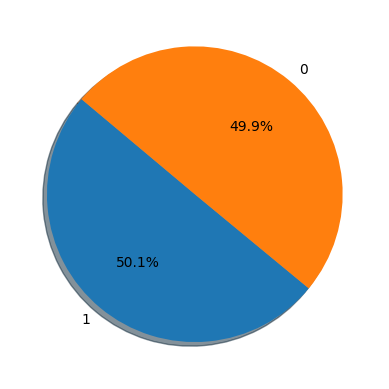

In [121]:

#Pie chart of sentiment

sentiment_count = df["sentiment"].value_counts()

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140
)

plt.show()

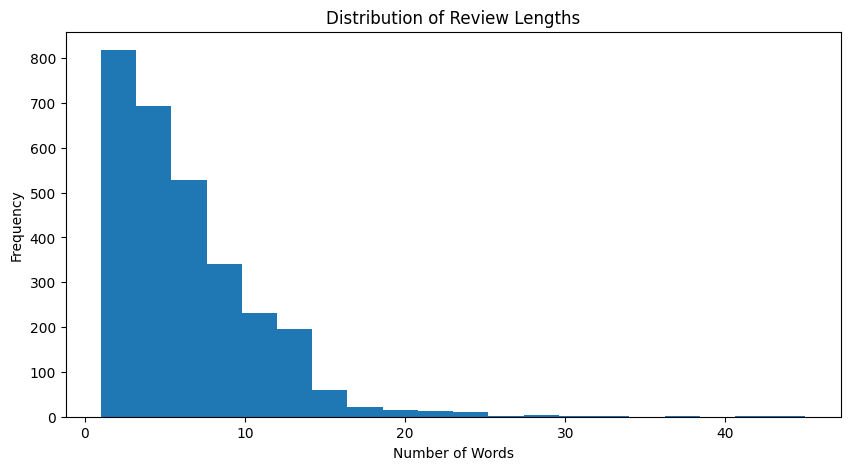

In [122]:
#Histogram of the sentence length

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["total_words"], bins=20)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [123]:
#Checking to see what is the upper quartile word count for sentences (Aka anything past is an outlier)

q1 = df["total_words"].quantile(0.25)
q3 = df["total_words"].quantile(0.75)

iqr = q3 - q1

upper_fence = q3 + 1.5 * iqr

print(upper_fence)

15.5


Dr. Sewell pretty much says that maximum sentence length isn't a law but a hyperparameter that is debated.


In [125]:
q1 = df["total_words"].quantile(0.25)
q3 = df["total_words"].quantile(0.75)

print(q1)
print(q3)
upper_fence = q3 + 1.5 * iqr

removed = (df["total_words"] > upper_fence).sum()

print("Reviews removed:", removed)
print("Percent removed:", round(removed / len(df) * 100, 2), "%")

3.0
8.0
Reviews removed: 95
Percent removed: 3.23 %


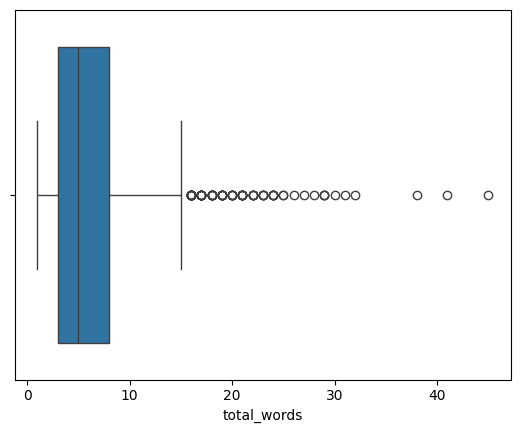

In [126]:
sns.boxplot(x=df["total_words"])
plt.show()

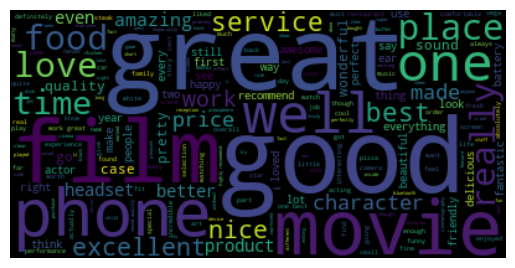

In [127]:

#positive word cloud

pos_reviews = df[df["sentiment"] == 1]

txt = " ".join(review.lower() for review in pos_reviews["review"])

wordcloud = WordCloud().generate(txt)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

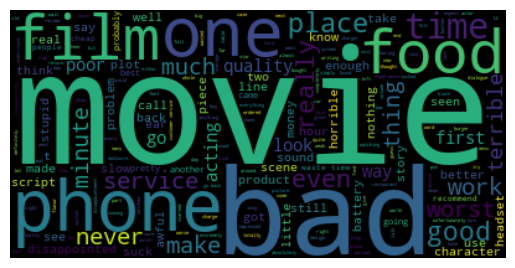

In [128]:
#negative word cloud

neg_reviews = df[df["sentiment"] == 0]

txt = " ".join(review.lower() for review in neg_reviews["review"])

wordcloud = WordCloud().generate(txt)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [129]:
#Settling on 16 words as max for sentence length. Must filter the data to only have 16 words max

# Remove length outliers using IQR upper fence
df = df[df["total_words"] <= 16].copy()

print(df.shape)

(2866, 4)


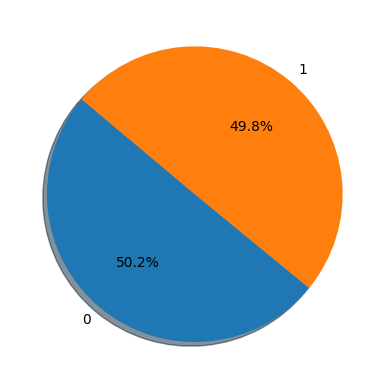

In [130]:
#Pie chart again
#Pie chart of sentiment

sentiment_count = df["sentiment"].value_counts()

plt.pie(
    sentiment_count,
    labels=sentiment_count.index,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140
)

plt.show()

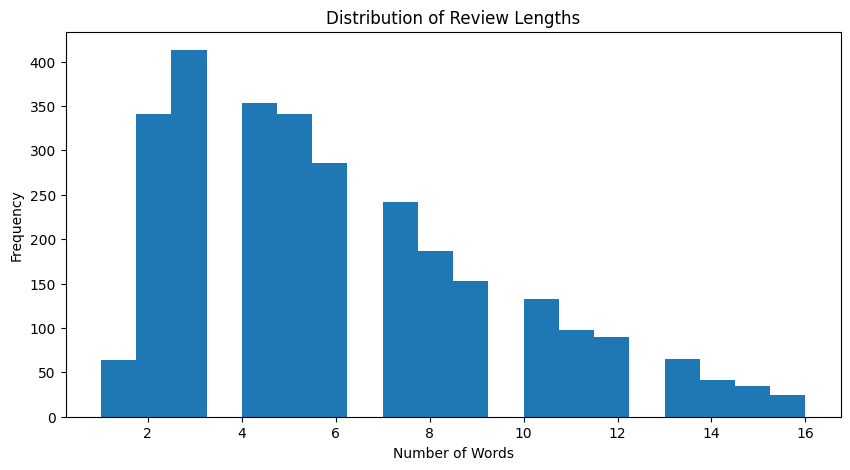

In [131]:

#Now recheck 
#Histogram of the sentence length

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["total_words"], bins=20)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Tokenize step


In [133]:
# Create a tokenizer to build a vocabulary from the cleaned review text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['review'])

# Convert text reviews into integer sequences, basically Vectorize

sequences = tokenizer.texts_to_sequences(df["review"])

df['sequence'] = sequences
print(df['sequence'].head(10))
print(df['review'].head(10))

0     [355, 355, 147, 611, 1909, 2, 1910, 1911, 1247...
1          [188, 402, 612, 39, 728, 729, 357, 537, 290]
3                              [63, 175, 234, 917, 453]
4       [18, 78, 2, 1912, 403, 148, 454, 291, 538, 539]
5      [455, 2, 540, 235, 456, 730, 1913, 14, 358, 613]
6                                        [359, 59, 104]
7               [257, 2, 360, 128, 1, 731, 1, 918, 292]
8                                            [199, 320]
9                     [134, 614, 1914, 236, 1915, 1916]
10                                     [919, 1917, 732]
Name: sequence, dtype: object
0     very very slow moving aimless movie distressed...
1     sure lost flat character audience nearly half ...
3                        little music anything speak of
4     best scene movie gerardo trying find song keep...
5     rest movie lack art charm meaning emptiness wo...
6                                       wasted two hour
7     saw movie today thought good effort good messa...
8                 

In [134]:
# Determine vocabulary size for use in the embedding layer
# Adding 1 reserves an index for padding. Recall that padding is a 0, hence why once is added 
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 4264


In [135]:
#okay Check some of the tokenized sequences and see if it worked

print(sequences[:5])

[[355, 355, 147, 611, 1909, 2, 1910, 1911, 1247, 356], [188, 402, 612, 39, 728, 729, 357, 537, 290], [63, 175, 234, 917, 453], [18, 78, 2, 1912, 403, 148, 454, 291, 538, 539], [455, 2, 540, 235, 456, 730, 1913, 14, 358, 613]]


THis looks good and proper


A maximum sequence length of 16 was selected after removing review-length outliers using the IQR upper fence justified in question B1


In [138]:
# Set the maximum sequence length to 16 words
# REviews longer than 16 words were removed as outliers using the iqr method


max_sequence_length = 16

In [139]:
# Pad all sequences to a uniform length required by TensorFlow
# Reviews shorter than 16 words receive padding at the end

X = pad_sequences(
    sequences,
    maxlen=max_sequence_length,
    padding='post',
    truncating='post'
)

df['padded'] = list(X)

#Let's check if the padded lines up 

print(df['padded'].head(10))
print(df['review'].head(10))




0     [355, 355, 147, 611, 1909, 2, 1910, 1911, 1247...
1     [188, 402, 612, 39, 728, 729, 357, 537, 290, 0...
3     [63, 175, 234, 917, 453, 0, 0, 0, 0, 0, 0, 0, ...
4     [18, 78, 2, 1912, 403, 148, 454, 291, 538, 539...
5     [455, 2, 540, 235, 456, 730, 1913, 14, 358, 61...
6     [359, 59, 104, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...
7     [257, 2, 360, 128, 1, 731, 1, 918, 292, 0, 0, ...
8     [199, 320, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
9     [134, 614, 1914, 236, 1915, 1916, 0, 0, 0, 0, ...
10    [919, 1917, 732, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Name: padded, dtype: object
0     very very slow moving aimless movie distressed...
1     sure lost flat character audience nearly half ...
3                        little music anything speak of
4     best scene movie gerardo trying find song keep...
5     rest movie lack art charm meaning emptiness wo...
6                                       wasted two hour
7     saw movie today thought good effort good messa...
8                   

Okay padding works. great


In [141]:
df.columns


Index(['review', 'sentiment', 'total_words', 'total_chars', 'sequence',
       'padded'],
      dtype='str')

In [142]:
#Verify Shape

print(X.shape)

# Expected: filtered number of reviews and 16 word positions


y = df["sentiment"].values

print(y.shape)

(2866, 16)
(2866,)


In [143]:
print(X[:1])

print(y[:1])

[[ 355  355  147  611 1909    2 1910 1911 1247  356    0    0    0    0
     0    0]]
[0]


Split the Data into train and test sets


In [145]:
# Features (padded review sequences) and target labels
# Split data into 80% training, 10% validation, and 10% testing

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

# Split the remaining 20% equally into validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=1,
    stratify=y_temp
)

# Verify dataset dimensions
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (2292, 16)
X_val  : (287, 16)
X_test : (287, 16)


In [146]:
#Double checking to see if the train/test split is correct in percentage

print(df.shape)


(2866, 6)


In [147]:
print(2866 * .8)

2292.8


Okay the split checks out for X_train


In [149]:
# Verify that the split percentages are correct

print("Original dataset:", df.shape)
print("Expected training rows:", len(df) * 0.80)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Testing rows:", len(X_test))

Original dataset: (2866, 6)
Expected training rows: 2292.8
Training rows: 2292
Validation rows: 287
Testing rows: 287


In [150]:
#Export data
df.to_csv("cleaned_full_data.csv", index=False)

#Combine the split datasets SPECIFICALLY for exporting, do not alter the original

#Combine X_train and y_train together
train_df = pd.DataFrame(X_train)
train_df["sentiment"] = y_train
train_df.to_csv("train_dataset.csv", index=False)

#Combine X_val and y_val together
val_df = pd.DataFrame(X_val)
val_df["sentiment"] = y_val
val_df.to_csv("validation_dataset.csv", index=False)

#Combine X_test and y_test together
test_df = pd.DataFrame(X_test)
test_df["sentiment"] = y_test
test_df.to_csv("test_dataset.csv", index=False)



In [151]:
print(train_df.head())
print(val_df.head())
print(test_df.head())

     0    1    2     3     4    5    6    7  8  9  10  11  12  13  14  15  \
0  187  240    1     0     0    0    0    0  0  0   0   0   0   0   0   0   
1  213  548  539   462  1952   26  365    0  0  0   0   0   0   0   0   0   
2   64   52    2  1248    60  293   64  404  0  0   0   0   0   0   0   0   
3  163   84    8    85     0    0    0    0  0  0   0   0   0   0   0   0   
4  100  435   36  1658    75  255    0    0  0  0   0   0   0   0   0   0   

   sentiment  
0          1  
1          1  
2          1  
3          0  
4          0  
      0    1     2    3     4    5    6  7    8   9  10  11  12  13  14  15  \
0  1053  322   123   91   772    0    0  0    0   0   0   0   0   0   0   0   
1    41   92    23    3     0    0    0  0    0   0   0   0   0   0   0   0   
2  1357  719  1900  351     0    0    0  0    0   0   0   0   0   0   0   0   
3    15  114    15  638   163   57   29  6  652  15   0   0   0   0   0   0   
4    70  457    39  734  2554  783  641  0    0   0 

Okay looks good 


Make the sequential model


In [154]:
#Model 1
# Create LSTM model
# Embedding dimension: 128, LSTM:64
# Dropout used to reduce overfitting: 0.25

model = Sequential()
model.add(Input(shape=(max_sequence_length,)))
model.add(Embedding( input_dim=vocab_size, output_dim=128, input_length=max_sequence_length))
model.add(LSTM(64))
model.add(Dropout(0.25))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile( optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()




C:\Users\nam\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 16, 128)             │         545,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 597,313 (2.28 MB)

 Trainable params: 597,313 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [155]:
#Make history of training

history1 = model.fit( X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5039 - loss: 0.6942 - val_accuracy: 0.4983 - val_loss: 0.6910
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7749 - loss: 0.4872 - val_accuracy: 0.8084 - val_loss: 0.4412
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9215 - loss: 0.2181 - val_accuracy: 0.7840 - val_loss: 0.5433
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9555 - loss: 0.1478 - val_accuracy: 0.7631 - val_loss: 0.7225
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9668 - loss: 0.1080 - val_accuracy: 0.7596 - val_loss: 0.7236
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9734 - loss: 0.0892 - val_accuracy: 0.7526 - val_loss: 0.7060
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9847 - loss: 0.0623 - val_accuracy: 0.7456 - val_loss: 0.9456
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9860 - loss: 0.0536 - val_accuracy: 0.7526 - val_loss:

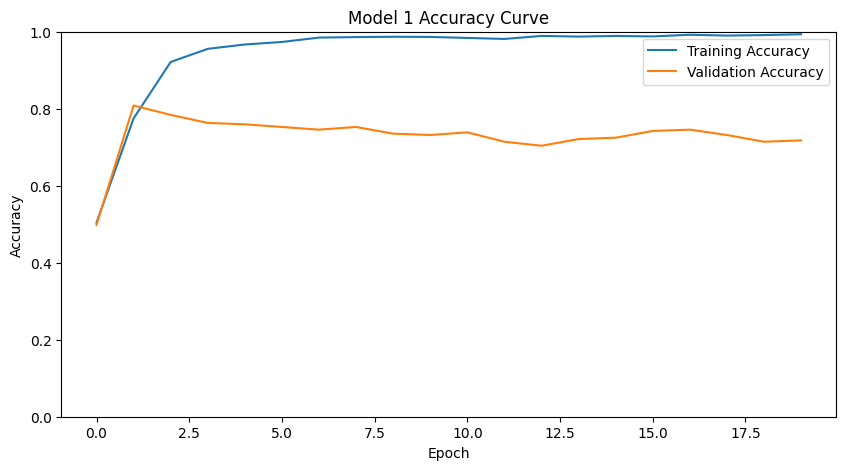

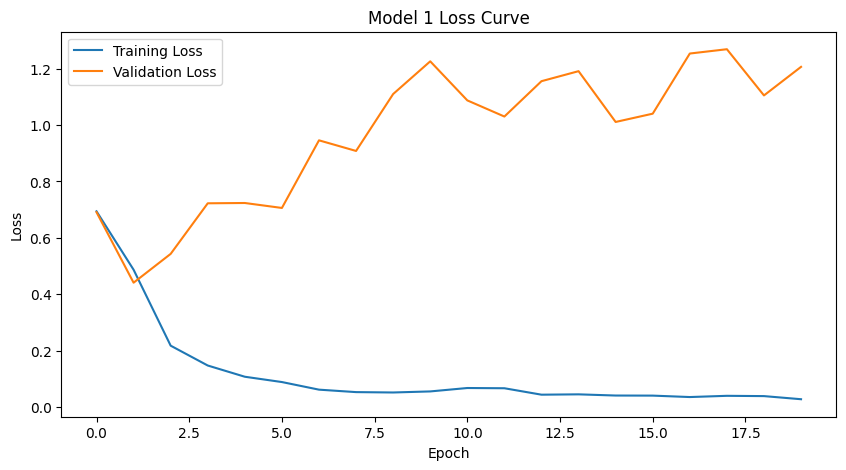

In [156]:
#Model 1 accuracy plot (Sewell, n.d.)
plt.figure(figsize=(10,5))
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()

#Model 1 loss curve   (Sewell, n.d.)
plt.figure(figsize=(10,5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [157]:
# Not satisified with the results, it shows clear overfitting, the model memorizes the training data too much
# Dr. Sewell is fine with above 70% val_accuracy but I want to aim for 80%

#Model 2

# Revised LSTM model to reduce overfitting
# Smaller embedding size, fewer LSTM units, higher dropout

model = Sequential()
model.add(Input(shape=(max_sequence_length,)))
model.add(Embedding(input_dim=vocab_size, output_dim=64))
model.add(LSTM(32))

model.add(Dropout(0.40))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile( optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


history2 = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)





Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5017 - loss: 0.6938 - val_accuracy: 0.5052 - val_loss: 0.6918
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7548 - loss: 0.5328 - val_accuracy: 0.7631 - val_loss: 0.4706
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9123 - loss: 0.2492 - val_accuracy: 0.7875 - val_loss: 0.5040
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9590 - loss: 0.1407 - val_accuracy: 0.7596 - val_loss: 0.6451


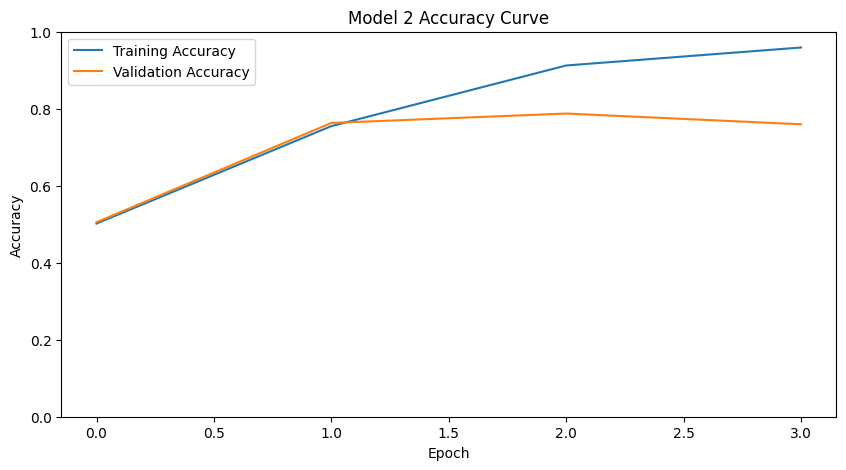

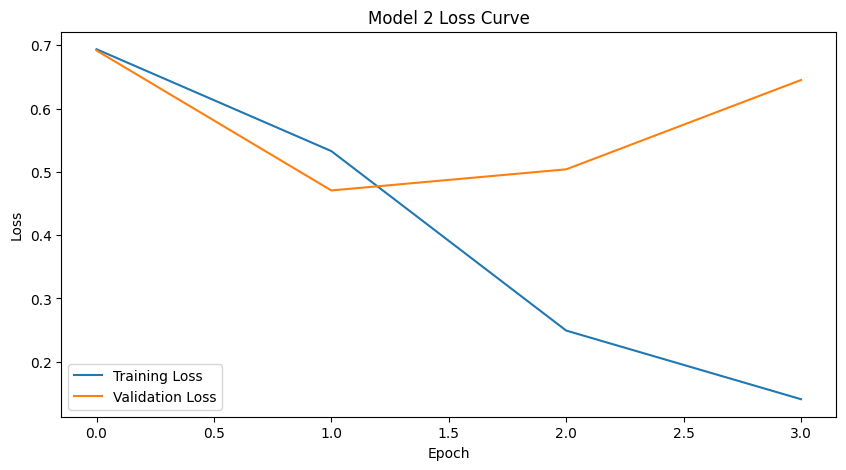

In [158]:
# Model 2 accuracy plot
plt.figure(figsize=(10,5))
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model 2 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0,1)

plt.legend(loc='best')
plt.show()

# Model 2 loss curve
plt.figure(figsize=(10,5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title('Model 2 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='best')
plt.show()

In [159]:
print("Best Validation Accuracy:", max(history2.history['val_accuracy']))
print("Lowest Validation Loss:", min(history2.history['val_loss']))

Best Validation Accuracy: 0.7874564528465271
Lowest Validation Loss: 0.47059521079063416


Okay I want to aim for at least 80% validation accuracy. While Dr. Sewell says 70% is fine, we're very close to getting 80%


In [161]:
#Model 3

model3 = Sequential()
model3.add(Input(shape=(max_sequence_length,)))
model3.add(Embedding(input_dim=vocab_size, output_dim=64))

model3.add(LSTM(64, dropout=0.20, recurrent_dropout=0.20))

model3.add(Dense(32, activation="relu"))
model3.add(Dropout(0.30))
model3.add(Dense(1, activation="sigmoid"))

optimizer = Adam(learning_rate=0.0005)

model3.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop3 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [162]:


history3 = model3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop3]
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4983 - loss: 0.6934 - val_accuracy: 0.4983 - val_loss: 0.6932
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5563 - loss: 0.6895 - val_accuracy: 0.7282 - val_loss: 0.6632
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8146 - loss: 0.4465 - val_accuracy: 0.7875 - val_loss: 0.4670
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9145 - loss: 0.2508 - val_accuracy: 0.8014 - val_loss: 0.4938
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9442 - loss: 0.1810 - val_accuracy: 0.7770 - val_loss: 0.5687
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9642 - loss: 0.1314 - val_accuracy: 0.7561 - val_loss: 0.6472


In [163]:

model3.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 16, 64)              │         272,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 924,101 (3.53 MB)

 Trainable params: 308,033 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 616,068 (2.35 MB)

In [164]:

print("Best Validation Accuracy:", max(history3.history["val_accuracy"]))
print("Lowest Validation Loss:", min(history3.history["val_loss"]))

Best Validation Accuracy: 0.8013937473297119
Lowest Validation Loss: 0.4669837951660156


Okay not even touching 80% accuracy bnut the validation loss is so much better now. 


In [166]:
model4 = Sequential()

model4.add(Input(shape=(max_sequence_length,)))
model4.add(Embedding(input_dim=vocab_size, output_dim=32))

model4.add(LSTM(48, dropout=0.15, recurrent_dropout=0.15))

model4.add(Dense(64, activation="relu"))
model4.add(Dense(48, activation="relu"))
model4.add(Dropout(0.01))
model4.add(Dense(1, activation="sigmoid"))

optimizer4 = Adam(learning_rate=0.0005)

model4.compile(
    optimizer=optimizer4,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop4 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history4 = model4.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop4]
)

model4.summary()

print("Best Validation Accuracy:", max(history4.history["val_accuracy"]))
print("Lowest Validation Loss:", min(history4.history["val_loss"]))

Epoch 1/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4965 - loss: 0.6933 - val_accuracy: 0.4878 - val_loss: 0.6932
Epoch 2/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5833 - loss: 0.6784 - val_accuracy: 0.7422 - val_loss: 0.5578
Epoch 3/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8460 - loss: 0.3828 - val_accuracy: 0.7805 - val_loss: 0.4622
Epoch 4/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.2457 - val_accuracy: 0.8049 - val_loss: 0.4672
Epoch 5/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9442 - loss: 0.1641 - val_accuracy: 0.7805 - val_loss: 0.5209
Epoch 6/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9586 - loss: 0.1331 - val_accuracy: 0.7700 - val_loss: 0.5710
Epoch 7/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9708 - loss: 0.1066 - val_accuracy: 0.7735 - val_loss: 0.6558
Epoch 8/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9773 - loss: 0.0771 - val_accuracy: 0.7422 - val_loss

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 16, 32)              │         136,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 48)                  │          15,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 48)                  │           3,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 474,917 (1.81 MB)

 Trainable params: 158,305 (618.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 316,612 (1.21 MB)

Best Validation Accuracy: 0.8048780560493469
Lowest Validation Loss: 0.4621770679950714



just got 80% val_accuracy and a lower val_loss

Remember to compare it to model 1
Adding another node layer did help

Cutting the embedding layer did help


Model 4 will be the final model




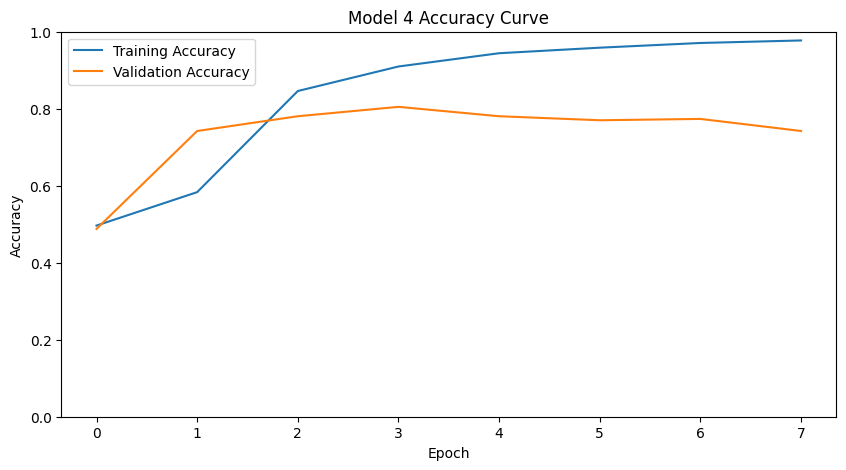

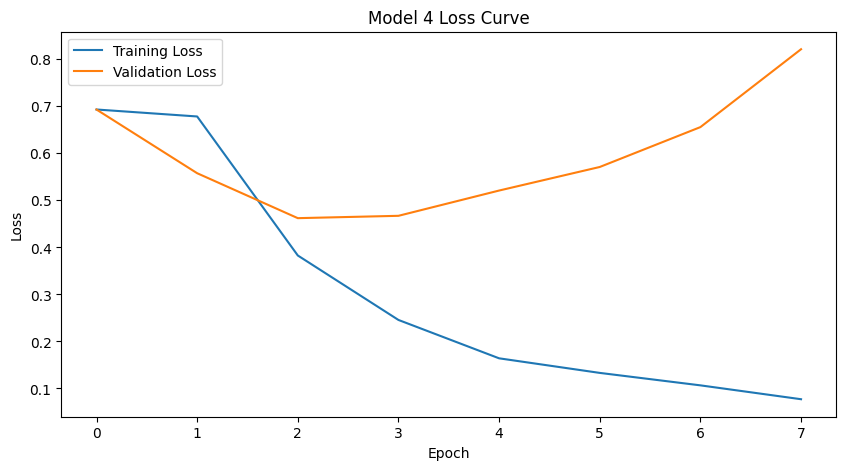

In [313]:
# Model 4 Accuracy Curve

plt.figure(figsize=(10,5))
plt.plot(history4.history['accuracy'], label='Training Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model 4 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0,1)

plt.legend(loc='best')
plt.show()


# Model 4 Loss Curve

plt.figure(figsize=(10,5))
plt.plot(history4.history['loss'], label='Training Loss')
plt.plot(history4.history['val_loss'], label='Validation Loss')

plt.title('Model 4 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='best')
plt.show()

In [321]:
#Now do it on test set

test_loss, test_accuracy = model4.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7944 - loss: 0.5104
Test Accuracy: 0.7944250702857971
Test Loss: 0.510386049747467


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


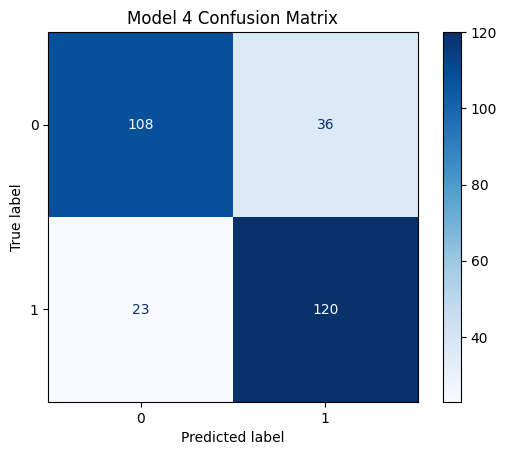

In [331]:
#Make Confusion Matrix (Sewell, n.d.)

predictions = (model4.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Model 4 Confusion Matrix")
plt.show()

In [333]:
#Write stats for confusion matrix

tn = 108
fp = 36
fn = 23
tp = 120

population = tp + tn + fp + fn

accuracy = (tp + tn) / population

precision = tp / (tp + fp)

recall = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Accuracy:", (accuracy * 100))
print("Precision:", (precision * 100))
print("Recall:", (recall * 100))
print("Specificity:", (specificity * 100))

Accuracy: 79.44250871080139
Precision: 76.92307692307693
Recall: 83.91608391608392
Specificity: 75.0


In [337]:
#Save the model

model4.save("Trained_Model.keras")